###Experiment 3: Implementation and analysis of Spatial Filtering Techniques using low-pass and High-pass Filters
Name- Abhigyan Dubey

Course & Branch- B.TECH CSE

CUID- CU24250059

SUBJECT - Computer Vision Lab

SEM & Section - 5th SEM , "B"

GitHub Repo Link -> https://github.com/cu24250059pixel/Computer_vision_Lab_sheets_5thSem

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img_color = cv2.imread(image_path)
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_color, cv2.COLOR_RGB2GRAY)

Saving download (11).jpg to download (11).jpg


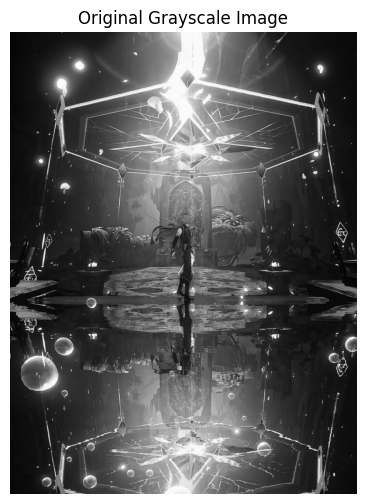

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

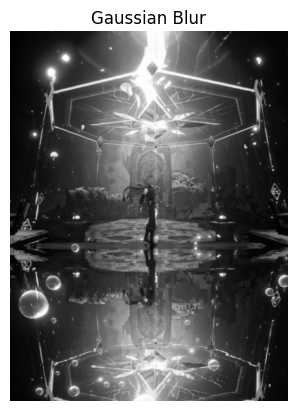

In [ ]:
gaussian_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

plt.imshow(gaussian_blur, cmap='gray')
plt.title("Gaussian Blur")
plt.axis('off')
plt.show()

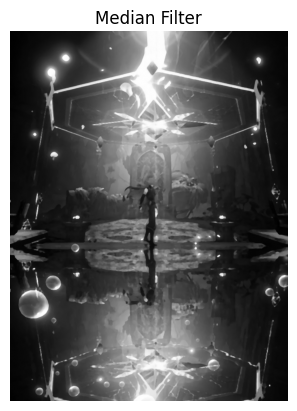

In [ ]:
median_blur = cv2.medianBlur(img_gray, 5)

plt.imshow(median_blur, cmap='gray')
plt.title("Median Filter")
plt.axis('off')
plt.show()

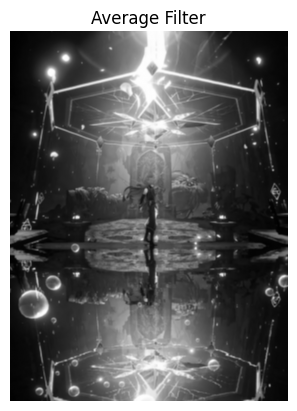

In [ ]:
average_blur = cv2.blur(img_gray, (5, 5))

plt.imshow(average_blur, cmap='gray')
plt.title("Average Filter")
plt.axis('off')
plt.show()

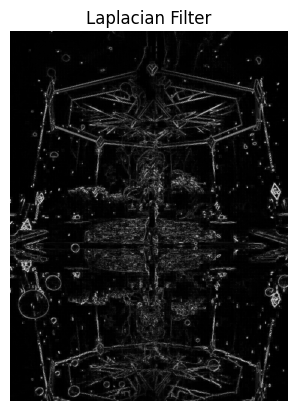

In [ ]:
laplacian = cv2.Laplacian(img_gray, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

plt.imshow(laplacian, cmap='gray')
plt.title("Laplacian Filter")
plt.axis('off')
plt.show()

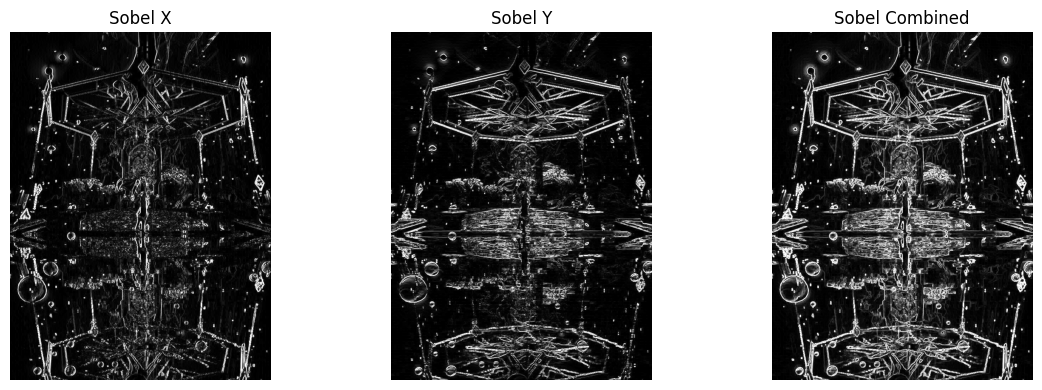

In [ ]:
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)
sobel_combined = cv2.bitwise_or(sobel_x, sobel_y)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(sobel_x, cmap='gray'); plt.title("Sobel X"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(sobel_y, cmap='gray'); plt.title("Sobel Y"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(sobel_combined, cmap='gray'); plt.title("Sobel Combined"); plt.axis('off')
plt.tight_layout()
plt.show()

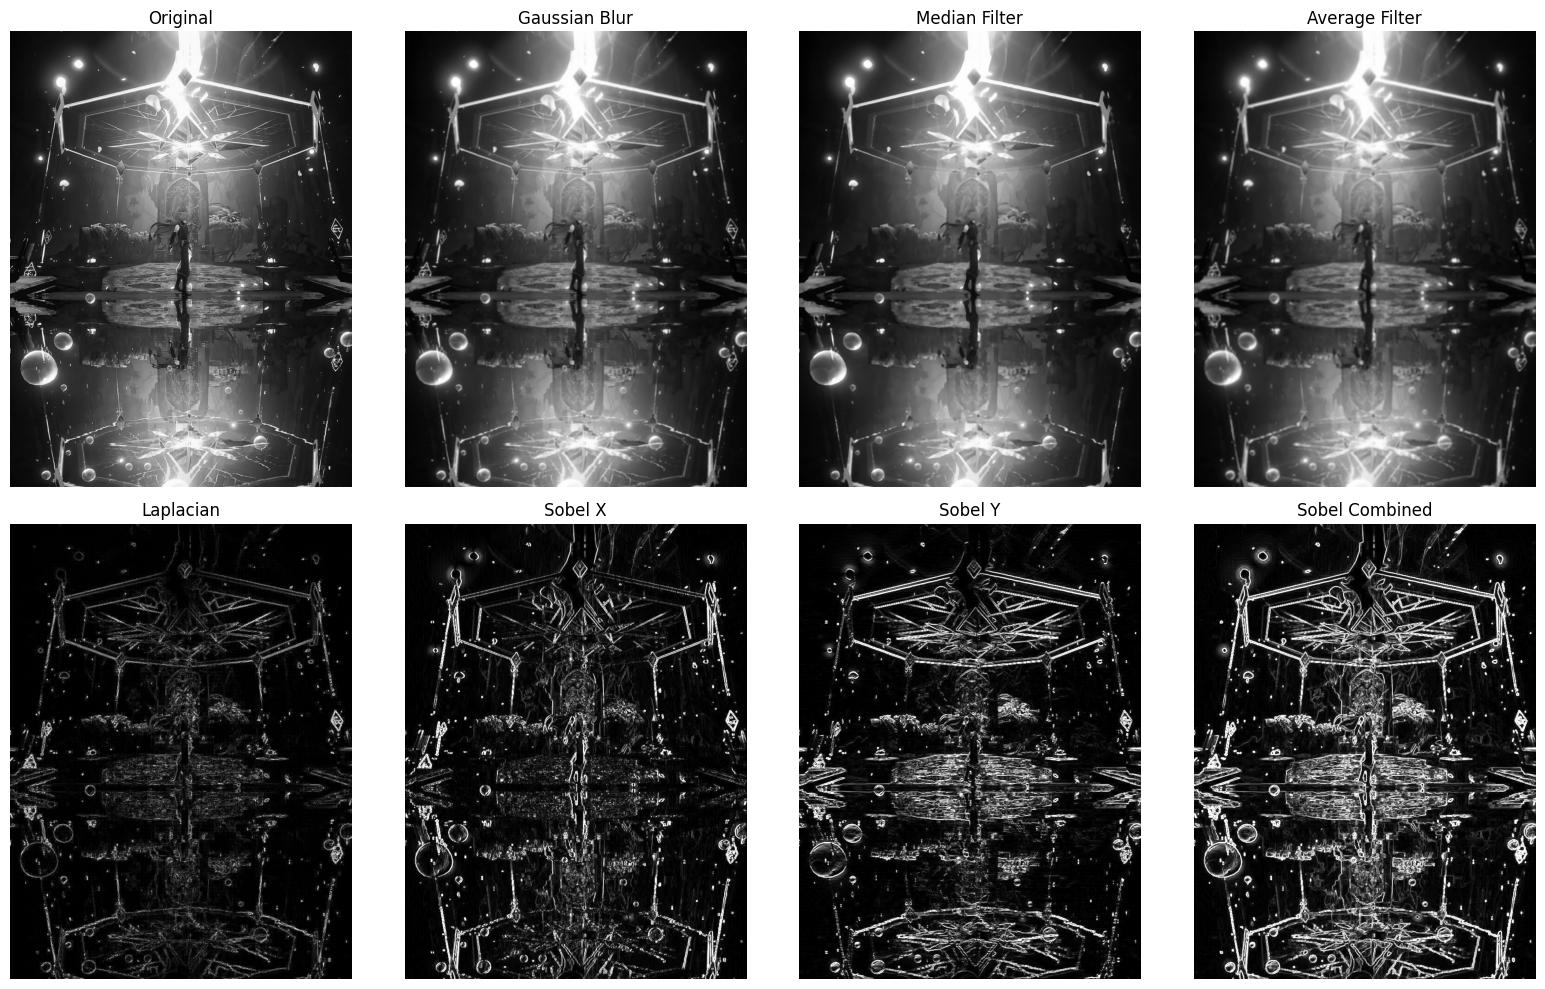

In [ ]:
titles = ['Original', 'Gaussian Blur', 'Median Filter', 'Average Filter',
          'Laplacian', 'Sobel X', 'Sobel Y', 'Sobel Combined']
images = [img_gray, gaussian_blur, median_blur, average_blur,
          laplacian, sobel_x, sobel_y, sobel_combined]

plt.figure(figsize=(16, 10))
for i in range(len(images)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

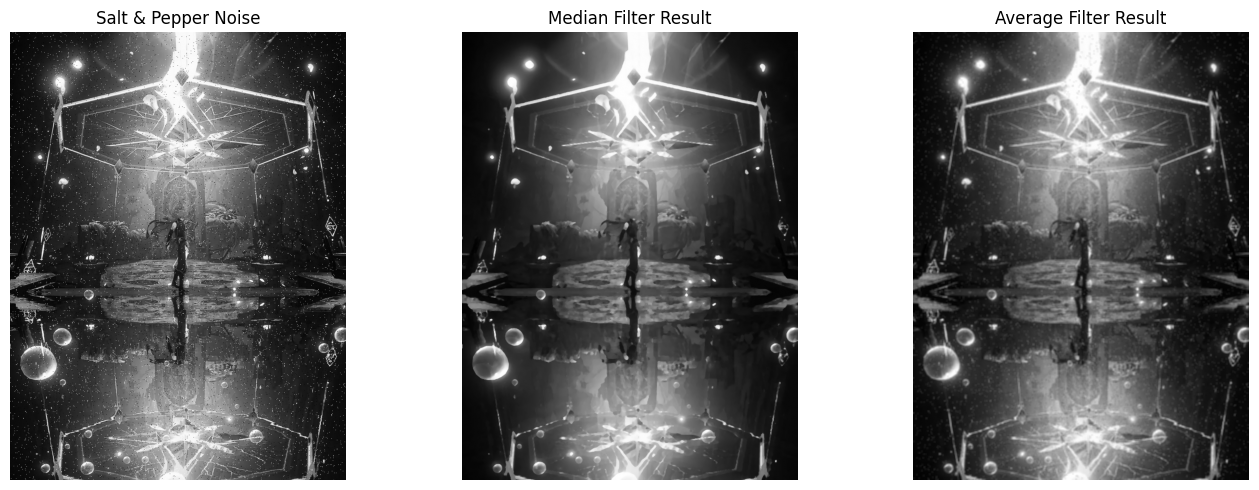

In [ ]:
def add_salt_pepper_noise(image, amount=0.02):
    noisy = np.copy(image)
    num_salt = np.ceil(amount * image.size * 0.5)
    num_pepper = np.ceil(amount * image.size * 0.5)

    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[coords[0], coords[1]] = 255

    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

noisy_img = add_salt_pepper_noise(img_gray)
median_denoised = cv2.medianBlur(noisy_img, 5)
average_denoised = cv2.blur(noisy_img, (5, 5))

plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1); plt.imshow(noisy_img, cmap='gray'); plt.title("Salt & Pepper Noise"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(median_denoised, cmap='gray'); plt.title("Median Filter Result"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(average_denoised, cmap='gray'); plt.title("Average Filter Result"); plt.axis('off')
plt.tight_layout()
plt.show()

Question Answers

**1. What is spatial filtering?**

Ans-> Spatial filtering is an image enhancement technique that modifies a pixel's value based on the values of its neighboring pixels, using a small matrix called a kernel (or mask) that slides over the image via convolution. It's used for smoothing, sharpening, noise removal, and edge detection directly in the pixel domain (as opposed to transforming to frequency domain first).

**2. Differentiate between Low-Pass Filters and High-Pass Filters with suitable examples.**

Ans->
*   Low-pass filters allow slow variations (smooth regions) to pass through while suppressing high-frequency components like noise and edges — result: blurred/smoothed image. Examples: Gaussian, Average/Mean, Median.
*   High-pass filters suppress slow variations and emphasize high-frequency components like edges and fine details — result: sharpened image with enhanced boundaries. Examples: Laplacian, Sobel, Prewitt.



**3. Compare Average Filter, Gaussian Filter, and Median Filter based on their working principles and applications**

Ans-> Average, Gaussian, and Median filters all smooth images but work differently. The Average Filter replaces each pixel with the plain mean of its neighborhood, causing heavy blurring of edges. The Gaussian Filter uses a weighted average (more weight to center pixels), giving smoother results with better edge preservation. The Median Filter replaces each pixel with the median value of its neighborhood, making it ideal for removing salt-and-pepper noise without blurring edges much, unlike the other two.

**4. Why is the Median Filter particularly effective for removing salt-and-pepper noise?**

Ans-> Salt-and-pepper noise appears as extreme outlier pixel values (pure black/white). Since the median is not influenced by outliers the way a mean is, sorting the neighborhood and picking the middle value effectively discards these extreme values while preserving edges and detail better than averaging filters.

**5. Explain the role of convolution kernels in spatial filtering.**

Ans->A kernel is a small matrix (e.g., 3×3, 5×5) that defines the filtering operation. It's slid across the image, and at each position, an element-wise multiplication with the underlying pixel neighborhood is summed to produce the new pixel value. The kernel's coefficients determine whether the filter smooths (low-pass) or sharpens/detects edges (high-pass).

**6. What is the purpose of the Sobel and Laplacian operators in edge detection?**

Ans->

Sobel computes the first-order gradient of intensity in horizontal (Gx) and vertical (Gy) directions, highlighting edges and their orientation — useful for detecting directional intensity changes.
Laplacian computes the second-order derivative, detecting edges regardless of direction and highlighting regions of rapid intensity change (zero-crossings), often more sensitive to noise.

**7. Why are filtering operations considered an essential preprocessing step in computer vision?**

Ans-> Raw images often contain noise, poor contrast, or irrelevant detail that can degrade the performance of downstream tasks like object detection, segmentation, and recognition. Filtering cleans and enhances the image — reducing noise (low-pass) or highlighting relevant structural features like edges (high-pass) — improving the accuracy and reliability of subsequent processing stages.

**8. Discuss the trade-off between image smoothing and edge preservation during filtering.**

Ans-> Smoothing filters reduce noise but blur edges/fine details as neighborhood size or averaging strength increases. Sharpening/high-pass filters preserve and enhance edges but amplify noise since noise itself is a high-frequency component. Choosing filter type/kernel size involves balancing noise suppression against detail retention — larger kernels smooth more but lose finer structures.

**9. Mention four real-world applications where spatial filtering techniques are widely used.**

Ans ->

Medical imaging (noise reduction in MRI/CT scans, edge detection for tumor boundaries)
Remote sensing and satellite imagery (enhancing terrain features, reducing atmospheric noise)
Surveillance and security systems (noise removal, motion/edge detection)
Autonomous vehicles/robotics (lane detection, obstacle edge detection via Sobel/Canny-based pipelines)


**10. Compare spatial domain filtering with frequency domain filtering in terms of implementation and practical applications.**

Ans->

Spatial domain: operates directly on pixel values using convolution with kernels; computationally simple and intuitive, well-suited for smaller kernels and real-time applications, but can be slower for very large kernels.
Frequency domain: transforms image into frequency components (via Fourier Transform), applies filters (e.g., ideal, Butterworth) by removing/keeping certain frequency ranges, then transforms back; more efficient for large-scale/global filtering operations and gives clearer control over frequency components, but adds computational overhead of transform/inverse-transform and is less intuitive for localized operations.